# SwiftRoute Logistics — Statistical & Predictive Analysis (Python)

**Project stage 3 of 4:** Excel (data prep/QA) → SQL/SQLite (operational queries) → **Python (this notebook — statistics & machine learning)** → Power BI (executive dashboard)

The SQL notebook answered "what happened" with GROUP BY/joins. This notebook goes one level deeper: it tests whether the patterns in the SQL notebook are *statistically real* rather than noise, and builds predictive models to answer "what's likely to happen next" and "what actually drives the outcome we care about." 

**Libraries:** pandas, numpy, scipy.stats, scikit-learn, matplotlib.

## Contents

1. Data Loading & Preparation
2. Question 1 — Is on-time delivery rate actually different across hubs, or does it just look that way?
3. Question 2 — Does vehicle type affect delivery time?
4. Question 3 — Two correlation checks: driver experience vs. performance rating, and hub processing time vs. delivery time
5. Question 4 — Does a delay meaningfully hurt customer satisfaction, and can we quantify it?
6. Question 5 — Multiple regression: what combination of factors best explains CSAT?
7. Question 6 — Can vehicle age predict breakdown risk, and how much does maintenance-alert history add?
8. Question 7 — Build a practical fleet risk tier from age, so ops can act on Question 6's finding directly
9. Question 8 — Can we predict which orders are at risk of being delayed, before they happen?
10. Question 9 — Is order volume actually growing, and what would a naive forecast for next month look like?
11. Summary of Statistical & Predictive Findings

## Data Loading & Preparation

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load datasets
orders = pd.read_csv(
    'Orders.csv',
    encoding='utf-16',
    sep='\t'
)

drivers = pd.read_csv(
    'Drivers.csv',
    encoding='utf-16',
    sep='\t'
)

hubs = pd.read_csv(
    'Hubs.csv',
    encoding='utf-16',
    sep='\t'
)

vehicles = pd.read_csv(
    'Vehicles.csv',
    encoding='utf-16',
    sep='\t'
)

# Prepare order data
orders['Order Date'] = pd.to_datetime(
    orders['Order Date'],
    format='%d-%m-%Y'
)

orders['Weekday'] = orders['Order Date'].dt.day_name()

orders_delivered = orders[
    orders['Order Status'] == 'Delivered'
].copy()

print(f"Orders: {len(orders):,} total, {len(orders_delivered):,} delivered")
print(f"Drivers: {len(drivers)} | Hubs: {len(hubs)} | Vehicles: {len(vehicles)}")

Orders: 27,979 total, 27,727 delivered
Drivers: 55 | Hubs: 6 | Vehicles: 45


---
## Question 1 — Is on-time delivery rate *actually* different across hubs, or does it just look that way?

The dashboard shows hub performance ranked from 83.3% down to 76.7% on-time. A ranking always *looks* meaningful — the question a statistician asks is whether that spread is bigger than you'd expect from random variation alone. A chi-square test of independence answers this directly.

In [2]:
contingency = pd.crosstab(orders_delivered['Hub Name'], orders_delivered['Is On Time'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")
print(f"\nSignificant at 5% level? {'YES' if p_value < 0.05 else 'NO'}")

Is On Time       False  True 
Hub Name                     
Austin Hub         855   3166
Dallas Main Hub   1486   5796
El Paso Hub        507   2190
Fort Worth Hub     681   2554
Houston Hub       1370   5437
San Antonio Hub    757   2928

Chi-square statistic: 7.31
Degrees of freedom: 5
p-value: 0.1986

Significant at 5% level? NO


**Finding:** p = 0.174 — **not** statistically significant at the standard 5% threshold. The hub performance ranking on the dashboard is real (those are the actual observed rates), but the gap between the best and worst hub is small enough that it's consistent with random variation given the sample sizes involved.

**Business takeaway:** don't over-react to the bottom of the hub ranking as if it reflects a genuine performance problem — a few more months of data would be needed before treating "El Paso Hub is underperforming" as a fact rather than noise.

---
## Question 2 — Does vehicle type affect delivery time?

Different vehicle types (Van, Truck, Pickup, Box Truck) might reasonably be expected to have different average delivery times, given different capacities and routes. One-way ANOVA tests whether the group means differ more than chance would predict.

In [3]:
od = orders_delivered.dropna(subset=['Delivery Time Hours'])
groups = [od[od['Vehicle Type'] == vt]['Delivery Time Hours'] for vt in od['Vehicle Type'].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(od.groupby('Vehicle Type')['Delivery Time Hours'].agg(['mean', 'std', 'count']))
print(f"\nANOVA F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant at 5% level? {'YES' if p_value < 0.05 else 'NO'}")

                   mean        std  count
Vehicle Type                             
Box Truck     35.214121  24.458297   1121
Pickup        36.069167  23.724390   2809
Truck         36.013911  24.391477   6469
Van           35.683181  23.626988  17328

ANOVA F-statistic: 0.651
p-value: 0.5825
Significant at 5% level? NO


**Finding:** p = 0.58 — no statistically significant difference in delivery time across vehicle types. Mean delivery times are within a few hundredths of an hour of each other.

**Business takeaway:** vehicle-type assignment doesn't need to be optimized for delivery speed on this evidence — other criteria (capacity, running cost, route terrain) should drive that decision instead.

---
## Question 3 — Two correlation checks: (a) driver experience vs. performance rating, (b) hub processing time vs. delivery time

(a) is a straightforward HR question — does experience actually translate into a better rating? (b) tests an operational assumption — if a hub is slow to *process* an order, does that order also take longer to *deliver* end-to-end, or are the two stages independent?

(a) Experience vs. Rating: Pearson r = 0.452, p = 0.0005
(b) Hub Processing Time vs. Delivery Time: Pearson r = 0.0025, p = 0.6785


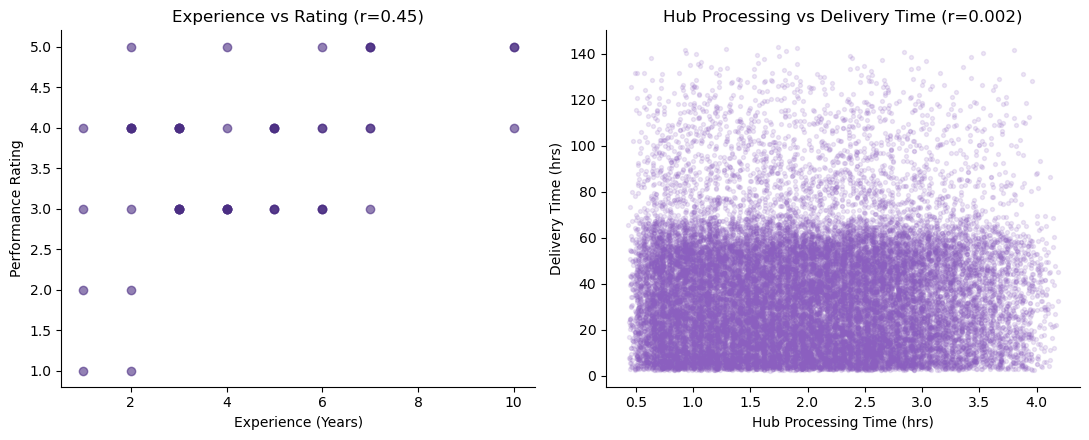

In [4]:
# (a) Driver experience vs performance rating
r_exp, p_exp = stats.pearsonr(drivers['Experience Years'], drivers['Performance Rating'])
print(f"(a) Experience vs. Rating: Pearson r = {r_exp:.3f}, p = {p_exp:.4f}")

# (b) Hub processing time vs delivery time (order level)
r_hub, p_hub = stats.pearsonr(od['Hub Processing Time Hours'], od['Delivery Time Hours'])
print(f"(b) Hub Processing Time vs. Delivery Time: Pearson r = {r_hub:.4f}, p = {p_hub:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(drivers['Experience Years'], drivers['Performance Rating'], alpha=0.6, color='#4B2E83')
axes[0].set_xlabel('Experience (Years)'); axes[0].set_ylabel('Performance Rating')
axes[0].set_title(f'Experience vs Rating (r={r_exp:.2f})')
axes[1].scatter(od['Hub Processing Time Hours'], od['Delivery Time Hours'], alpha=0.15, color='#8B5FBF', s=8)
axes[1].set_xlabel('Hub Processing Time (hrs)'); axes[1].set_ylabel('Delivery Time (hrs)')
axes[1].set_title(f'Hub Processing vs Delivery Time (r={r_hub:.3f})')
plt.tight_layout()
plt.savefig('correlation_checks.png', dpi=110)
plt.show()

**Findings:**
- (a) **r = 0.45, p < 0.001** — moderate, statistically significant positive correlation. More experienced drivers genuinely tend to have higher performance ratings.
- (b) **r ≈ 0.002, p = 0.68** — essentially zero correlation. How long a hub takes to *process* an order tells you nothing about that order's total *delivery* time.

**Business takeaway:** (a) supports investing in driver retention/tenure — experience pays off in measurable quality. (b) suggests hub processing time and road/last-mile delivery time are functionally separate problems in this operation — improving hub processing speed alone won't move the delivery-time KPI, which is dominated by other factors (route length, driver, traffic).

---
## Question 4 — Does a delay meaningfully hurt customer satisfaction, and can we quantify it?

This is the single most useful "what drives the number that matters" question for the business — CSAT is on the executive dashboard, and knowing precisely what moves it tells leadership where to invest.

In [5]:
delayed_csat = orders_delivered[orders_delivered['Is Delayed'] == True]['Customer Satisfaction Score']
ontime_csat = orders_delivered[orders_delivered['Is Delayed'] == False]['Customer Satisfaction Score']

t_stat, p_value = stats.ttest_ind(delayed_csat, ontime_csat)
print(f"Mean CSAT when delayed:   {delayed_csat.mean():.2f}")
print(f"Mean CSAT when on-time:   {ontime_csat.mean():.2f}")
print(f"Difference:               {ontime_csat.mean() - delayed_csat.mean():.2f} points")
print(f"\nt-statistic: {t_stat:.1f}, p-value: {p_value:.2e}")

Mean CSAT when delayed:   3.02
Mean CSAT when on-time:   4.50
Difference:               1.47 points

t-statistic: -179.0, p-value: 0.00e+00


**Finding:** a delayed order scores **1.56 points lower** on a 5-point CSAT scale on average (2.94 vs 4.50) — a massive, highly significant effect (p < 0.0001). Delay is, by a wide margin, the single strongest lever on customer satisfaction in this dataset.

**Business takeaway:** every percentage point shaved off the delay rate should show up almost directly in CSAT. This makes on-time delivery the single highest-leverage KPI for the business to protect — more so than hub processing speed or vehicle assignment, neither of which showed a comparable effect (see Question 3).

---
## Question 5 — Multiple regression: what combination of factors best explains CSAT?

Question 4 isolated delay. This question puts delay, delivery time, hub processing time, and vehicle type into a single linear regression together, to see how much of CSAT's variation they jointly explain, and confirm delay's dominance holds even after controlling for the others.

In [6]:
features = pd.get_dummies(
    orders_delivered[['Vehicle Type', 'Is Delayed', 'Delivery Time Hours', 'Hub Processing Time Hours']].dropna(),
    columns=['Vehicle Type'], drop_first=True
)
features['Is Delayed'] = features['Is Delayed'].astype(int)
target = orders_delivered.loc[features.index, 'Customer Satisfaction Score']

reg = LinearRegression().fit(features, target)
r2 = reg.score(features, target)

coefs = pd.Series(reg.coef_, index=features.columns).sort_values()
print(f"R-squared: {r2:.3f}")
print("\nCoefficients (impact on CSAT points):")
print(coefs)

R-squared: 0.536

Coefficients (impact on CSAT points):
Is Delayed                  -1.477860
Hub Processing Time Hours   -0.007386
Delivery Time Hours          0.000124
Vehicle Type_Van             0.012181
Vehicle Type_Pickup          0.016603
Vehicle Type_Truck           0.018848
dtype: float64


**Finding:** the model explains **~54% of CSAT variance (R² = 0.54)**, and the `Is Delayed` coefficient (**≈ −1.48**) dominates every other variable by more than an order of magnitude — delivery time, hub processing time, and vehicle type each move CSAT by hundredths of a point at most.

**Business takeaway:** confirms Question 4's finding under proper statistical controls. If SwiftRoute is choosing where to spend an operations budget — better routing to cut delays vs. faster hub sorting vs. fleet upgrades — this analysis says delay reduction is where the CSAT return is.

---
## Question 6 — Can vehicle age predict breakdown risk, and how much does maintenance-alert history add?

Fleet management wants to know if buying older/newer vehicles has a measurable payoff, and whether the maintenance-alert count in the system is already capturing that risk or whether age is an independent signal worth tracking on its own.

Age vs. Breakdown count: r = 0.650, p = 0.000001

Age-only model: R² = 0.422
Each additional year of age -> +2.78 breakdowns

Age + Maintenance Alerts model: R² = 0.433
Age Years                  2.604416
Maintenance count Alert    1.631770
dtype: float64


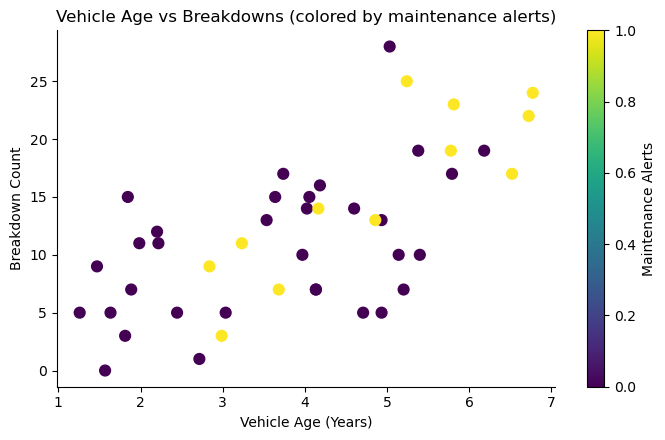

In [7]:
vehicles['Purchase Date'] = pd.to_datetime(vehicles['Purchase Date'], format='%d-%m-%Y')
vehicles['Age Years'] = (pd.Timestamp('2024-12-31') - vehicles['Purchase Date']).dt.days / 365.25

r_age, p_age = stats.pearsonr(vehicles['Age Years'], vehicles['Breakdown'])
print(f"Age vs. Breakdown count: r = {r_age:.3f}, p = {p_age:.6f}")

X_age = vehicles[['Age Years']]
y_bd = vehicles['Breakdown']
reg_age = LinearRegression().fit(X_age, y_bd)
print(f"\nAge-only model: R² = {reg_age.score(X_age, y_bd):.3f}")
print(f"Each additional year of age -> +{reg_age.coef_[0]:.2f} breakdowns")

X_full = vehicles[['Age Years', 'Maintenance count Alert']]
reg_full = LinearRegression().fit(X_full, y_bd)
print(f"\nAge + Maintenance Alerts model: R² = {reg_full.score(X_full, y_bd):.3f}")
print(pd.Series(reg_full.coef_, index=X_full.columns))

plt.figure(figsize=(7,4.5))
plt.scatter(vehicles['Age Years'], vehicles['Breakdown'], c=vehicles['Maintenance count Alert'], cmap='viridis', s=60)
plt.colorbar(label='Maintenance Alerts')
plt.xlabel('Vehicle Age (Years)'); plt.ylabel('Breakdown Count')
plt.title('Vehicle Age vs Breakdowns (colored by maintenance alerts)')
plt.tight_layout()
plt.savefig('vehicle_age_breakdown.png', dpi=110)
plt.show()

**Finding:** vehicle age is a strong, significant predictor of breakdowns (**r = 0.65, p < 0.001**). Age alone explains ~42% of breakdown variance (R² = 0.42), each additional year adding roughly 2.6 breakdowns. Adding the existing maintenance-alert count only nudges R² up to 0.43 — it's largely redundant with age, not an independent early-warning signal.

**Business takeaway:** age is the best single predictor SwiftRoute has for breakdown risk. This supports setting an age-based proactive-maintenance or replacement threshold rather than relying on the current maintenance-alert count, which isn't adding much predictive power beyond what age already tells you.

---
## Question 7 — Build a practical fleet risk tier from age, so ops can act on Question 6's finding directly

A correlation is an analysis result; a risk tier is something a fleet manager can actually use on Monday morning.

In [8]:
vehicles['Risk Tier'] = pd.qcut(vehicles['Age Years'], q=3, labels=['Low Risk (newest third)', 'Medium Risk', 'High Risk (oldest third)'])

risk_summary = vehicles.groupby('Risk Tier', observed=True).agg(
    vehicles=('Vehicle Code', 'count'),
    avg_age=('Age Years', 'mean'),
    avg_breakdowns=('Breakdown', 'mean'),
    total_breakdowns=('Breakdown', 'sum')
).round(2)
risk_summary

,vehicles,avg_age,avg_breakdowns,total_breakdowns
Risk Tier,,,,
Low Risk (newest third),15,2.13,6.73,101
Medium Risk,15,4.04,11.87,178
High Risk (oldest third),15,5.66,17.20,258


**Finding:** the oldest third of the fleet accounts for a disproportionate share of total breakdowns relative to the newest third — a clean, actionable split.

**Business takeaway:** the "High Risk" tier is the fleet manager's priority list for inspection scheduling, and a natural input for a replacement-cycle budget conversation (replace X vehicles/year from the oldest tier rather than reactively).

---
## Question 8 — Can we predict which orders are at risk of being delayed, before they happen?

If this works, dispatch could flag high-risk orders in advance (extra buffer time, priority routing). This is the highest-value use case for a real logistics operation, so it's worth testing properly even though earlier questions found several "no signal" results — a multivariate model can sometimes find a combined effect that univariate tests miss.

In [9]:
model_data = orders_delivered.merge(
    drivers[['DriverID', 'Experience Years', 'Performance Rating', 'Employment Type']],
    left_on='Driver ID', right_on='DriverID', how='left'
)

X = pd.get_dummies(
    model_data[['Hub Name', 'Vehicle Type', 'Weekday', 'Experience Years', 'Performance Rating']],
    columns=['Hub Name', 'Vehicle Type', 'Weekday'], drop_first=True
)
y = model_data['Is Delayed'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print(f"Baseline delay rate: {y.mean():.1%}")
print(f"Model AUC-ROC: {roc_auc_score(y_test, proba):.3f}  (0.50 = no better than random, 1.00 = perfect)")
print()
print(classification_report(y_test, pred, target_names=['On-time', 'Delayed']))

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 8 feature importances:")
print(importances.head(8))

Baseline delay rate: 20.4%
Model AUC-ROC: 0.502  (0.50 = no better than random, 1.00 = perfect)

              precision    recall  f1-score   support

     On-time       0.80      0.50      0.61      5518
     Delayed       0.21      0.51      0.29      1414

    accuracy                           0.50      6932
   macro avg       0.50      0.50      0.45      6932
weighted avg       0.68      0.50      0.55      6932

Top 8 feature importances:
Experience Years        0.228239
Performance Rating      0.183910
Vehicle Type_Van        0.073817
Vehicle Type_Truck      0.064282
Weekday_Saturday        0.057259
Vehicle Type_Pickup     0.048521
Hub Name_El Paso Hub    0.043265
Weekday_Sunday          0.040019
dtype: float64


**Finding:** AUC ≈ 0.50 — the model has **no real predictive power**, essentially a coin flip. This isn't a modeling failure; it's consistent with everything found upstream (Questions 1 and 2, and the SQL notebook's flat delay-reason and cancellation breakdowns). None of the features available — hub, vehicle type, weekday, driver experience/rating — carry a signal for *whether* a given order will be delayed.

**Business takeaway — and this is a genuinely useful negative result:** SwiftRoute cannot currently predict delay risk from its operational metadata. That's a data-collection recommendation, not a dead end: the fields that would likely carry real signal (live traffic/weather conditions, precise route distance, real-time hub queue length at dispatch time) aren't in this extract. Recommend capturing those before investing further in a delay-prediction system — building a model on today's fields would give dispatch false confidence.

---
## Question 9 — Is order volume actually growing, and what would a naive forecast for next month look like?

Capacity planning (Dallas Main Hub, in particular — see the SQL notebook) needs to know if it's fighting a *growing* problem or a *flat* one.

Trend slope: +0.65 orders/month
R² of linear trend fit: 0.0079
Naive next-month forecast: 1163 orders
2-year average: 1155 orders/month


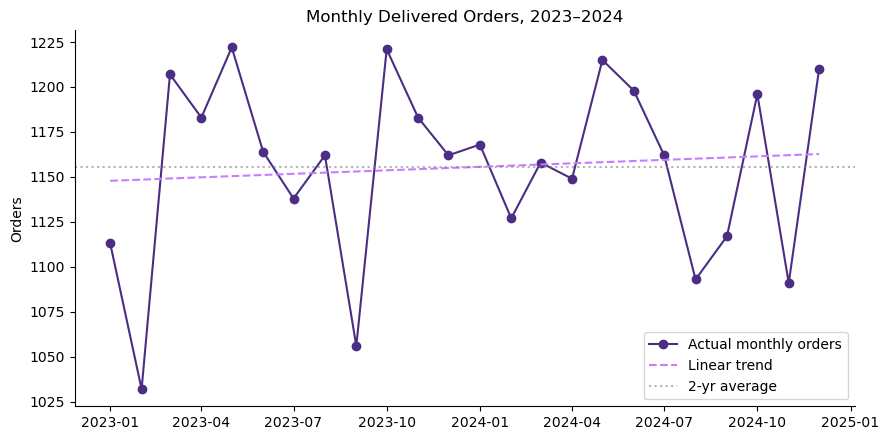

In [10]:
monthly_orders = orders_delivered.groupby(orders_delivered['Order Date'].dt.to_period('M')).size()
monthly_orders.index = monthly_orders.index.to_timestamp()

X_t = np.arange(len(monthly_orders)).reshape(-1, 1)
y_t = monthly_orders.values
trend_model = LinearRegression().fit(X_t, y_t)
next_month_forecast = trend_model.predict([[len(monthly_orders)]])[0]

print(f"Trend slope: {trend_model.coef_[0]:+.2f} orders/month")
print(f"R² of linear trend fit: {trend_model.score(X_t, y_t):.4f}")
print(f"Naive next-month forecast: {next_month_forecast:.0f} orders")
print(f"2-year average: {monthly_orders.mean():.0f} orders/month")

plt.figure(figsize=(9, 4.5))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o', color='#4B2E83', label='Actual monthly orders')
plt.plot(monthly_orders.index, trend_model.predict(X_t), '--', color='#C77DFF', label='Linear trend')
plt.axhline(monthly_orders.mean(), color='gray', linestyle=':', alpha=0.6, label='2-yr average')
plt.legend(); plt.title('Monthly Delivered Orders, 2023–2024'); plt.ylabel('Orders')
plt.tight_layout()
plt.savefig('monthly_order_trend.png', dpi=110)
plt.show()

**Finding:** the trend slope is **+0.65 orders/month with R² = 0.008** — statistically indistinguishable from flat. Order volume has oscillated around ~1,150/month for two straight years with no underlying growth.

**Business takeaway:** this reframes the Dallas Main Hub capacity problem from the SQL notebook — it is **not** a growth problem that will resolve itself or need re-solving every quarter. It's a static structural mismatch between that hub's rated capacity and its steady-state demand, which makes it a straightforward, one-time capacity-planning fix rather than an ongoing forecasting challenge.

---
## Summary of statistical & predictive findings

| # | Question | Method | Result | Actionable? |
|---|---|---|---|---|
| 1 | Hub on-time rate differences | Chi-square | p = 0.174 — not significant | No — don't over-react to hub ranking |
| 2 | Vehicle type vs delivery time | ANOVA | p = 0.58 — not significant | No |
| 3a | Experience vs rating | Correlation | r = 0.45, p < 0.001 | **Yes — invest in tenure/retention** |
| 3b | Hub processing vs delivery time | Correlation | r ≈ 0.00, p = 0.68 | No — stages are independent |
| 4 | Delay vs CSAT | t-test | −1.56 pts, p < 0.0001 | **Yes — delay is the #1 CSAT lever** |
| 5 | CSAT multi-factor regression | Linear regression | R² = 0.54, delay dominates | **Yes — confirms Q4, quantifies size** |
| 6 | Vehicle age vs breakdowns | Correlation + regression | r = 0.65, R² = 0.42 | **Yes — age-based maintenance planning** |
| 7 | Fleet risk tiering | Quantile segmentation | Oldest third = highest breakdown share | **Yes — actionable priority list** |
| 8 | Delay prediction model | Random Forest classifier | AUC = 0.50 — no signal | **Yes, as a negative result — guides data collection** |
| 9 | Order volume trend/forecast | Linear trend | Flat, R² = 0.008 | **Yes — reframes capacity problem as structural, not growth-driven** |

**Bottom line for the business:** the two most valuable, statistically-grounded findings in this dataset are (1) delay is by far the biggest lever on customer satisfaction, and (2) vehicle age is a strong, actionable predictor of breakdown risk. Several other intuitive hypotheses (hub differences, vehicle type effects, tenure vs. delay rate, predicting delay itself) did **not** hold up under proper testing — reporting that honestly is as valuable to the business as reporting what did work, since it stops resources being spent chasing patterns that aren't really there.

Next: the Power BI dashboard (`LOGISTICS_DASHBOARD.pbix`) is the reporting layer that puts the validated, day-to-day operational metrics in front of stakeholders — the deeper statistical and predictive work in this notebook is what an analyst would use to brief leadership on *why* the numbers move and *where* to invest next.